# **✈ Avitation Flight Fare Prediction Model**

**![images.jpg](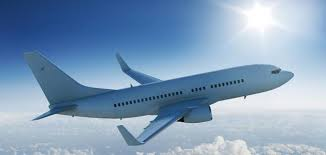 )**
      

**This application aims to predict flight ticket prices based on various factors.
Users can input details such as the airline, source, destination, and journey details to get an estimated price.**

*   **↪ Import Libraries**
*   **📁Load Data**
*   **🛠Pre-Processing:-**
      *   ❓ Missing value (Route-Column , Tptal_Stops-Column)
      *   🔃 Duplicates
      *   ✂ Drop Unimportant Columns
*   **📑Exploratory Data Analysis (EDA):-**
      *   Check Column Value
      *   Convert Column's Data Type
      *   Extract Data From Columns
      *   Process the Duration column
      *   Drop Unimportant Columns
      *   Check Outliers
      *   Save Clean Data
*   **📊Visualization:-**
      *   💹 Analysis by graphs
      *   🔗 Check Correlation
*   **🛠Feature Engineering:-**
      *   🔤Encoding
      *   📈Scalar
*   **💠Models:-**
      *   ✂️Spliting Data
      *   🔄Apply Models and Evaluation
      *   ✴The Best Model:-
          * Grid Search CV
          * Randomized Search CV
          * Apply best model
*   **🈺Application**



---



---



# **↪ Import Libraries**

In [133]:
# Load data & Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [134]:
#Models
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate , StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [135]:
from imblearn.pipeline import Pipeline as ImPipeline
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from imblearn.under_sampling import TomekLinks
import joblib

# **📁Load Data**

In [136]:
df = pd.read_excel("Data_Train.xlsx")
data_original = df.copy()
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


### **📑Discovering Data**


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [138]:
df.describe().round(1)

,Price
count,10683.0
mean,9087.1
std,4611.4
min,1759.0
25%,5277.0
50%,8372.0
75%,12373.0
max,79512.0


In [139]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [140]:
df.nunique()

,0
Airline,12
Date_of_Journey,44
Source,5
Destination,6
Route,128
Dep_Time,222
Arrival_Time,1343
Duration,368
Total_Stops,5
Additional_Info,10


# **🛠Pre-Processing**

*   Missing value (Route-Column , Tptal_Stops-Column)
*   Duplicates
*   Drop Unimportant Columns


## **❓Mising Value**

In [141]:
# nulls
df.isna().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [142]:
df.dropna(inplace=True) # Drop Mising Value

In [143]:
df.isna().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


## **🔃Duplicates**

In [144]:
# Duplicate
df.duplicated().sum()

220

In [145]:
df.drop_duplicates(inplace=True ,keep="first")

In [146]:
df.duplicated().sum()

0

## **✂ Drop Unimportant Columns**

In [147]:
df.drop(['Route'], axis = 1, inplace = True)

In [148]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Dep_Time',
       'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price'],
      dtype='object')

In [149]:
df.count()

,0
Airline,10462
Date_of_Journey,10462
Source,10462
Destination,10462
Dep_Time,10462
Arrival_Time,10462
Duration,10462
Total_Stops,10462
Additional_Info,10462
Price,10462


# **📑Exploratory Data Analysis (EDA)**

*   Check Value of Column
*   Convert Column's Data Type
*   Extract Data From Columns
*   Process the Duration column
*   Drop Unimportant Columns
*   Check Outliers
*   Save Clean Data

In [150]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Dep_Time',
       'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price'],
      dtype='object')

## **✅Ckeck Value of Column**

### **▶ object Column**

---



### **Airline_Column**

In [151]:
df["Airline"].value_counts()

,count
Airline,
Jet Airways,3700
IndiGo,2043
Air India,1694
Multiple carriers,1196
SpiceJet,815
Vistara,478
Air Asia,319
GoAir,194
Multiple carriers Premium economy,13


In [152]:
df['Airline'].nunique()

12

In [153]:
px.histogram(data_frame=df , x = "Airline")

### **Source_Column**

In [154]:
df["Source"].value_counts()

,count
Source,
Delhi,4345
Kolkata,2860
Banglore,2179
Mumbai,697
Chennai,381


In [155]:
df['Source'].nunique()

5

In [156]:
px.histogram(data_frame=df , x = "Source")

### **Destination_Column**

In [157]:
df["Destination"].value_counts()

,count
Destination,
Cochin,4345
Banglore,2860
Delhi,1265
New Delhi,914
Hyderabad,697
Kolkata,381


In [158]:
df['Destination'].nunique()

6

In [159]:
px.histogram(data_frame=df , x = "Destination")

### **Total_Stops_column**

In [160]:
df["Total_Stops"].value_counts()

,count
Total_Stops,
1 stop,5625
non-stop,3475
2 stops,1318
3 stops,43
4 stops,1


In [161]:
df['Total_Stops'] = df['Total_Stops'].str.replace('non-stop', '0')\
                                     .str.replace('1 stop','1')\
                                     .str.replace('2 stops','2')\
                                     .str.replace('3 stops','3')\
                                     .str.replace('4 stops','4')

In [162]:
df["Total_Stops"].value_counts()

,count
Total_Stops,
1,5625
0,3475
2,1318
3,43
4,1


In [163]:
df['Total_Stops'].nunique()

5

In [164]:
px.histogram(data_frame=df , x = "Total_Stops")

### **Additional_Info_Column**

In [165]:
df["Additional_Info"].value_counts()

,count
Additional_Info,
No info,8182
In-flight meal not included,1926
No check-in baggage included,318
1 Long layover,19
Change airports,7
Business class,4
No Info,3
1 Short layover,1
Red-eye flight,1


In [166]:
df['Additional_Info'] = df['Additional_Info'].str.replace('Info', 'info', case=False)

In [167]:
df["Additional_Info"].value_counts()

,count
Additional_Info,
No info,8185
In-flight meal not included,1926
No check-in baggage included,318
1 Long layover,19
Change airports,7
Business class,4
1 Short layover,1
Red-eye flight,1
2 Long layover,1


In [168]:
df['Additional_Info'].nunique()

9

In [169]:
px.histogram(data_frame=df , x = "Additional_Info")

### **⏰Time Column**

---



### **Date_of_Journey**

In [170]:
df['Date_of_Journey'].head()

,Date_of_Journey
0,24/03/2019
1,1/05/2019
2,9/06/2019
3,12/05/2019
4,01/03/2019


***📝1)Convert Column's Data Type***

In [171]:
#Convert date-related columns to datetime
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10462 non-null  object        
 1   Date_of_Journey  10462 non-null  datetime64[ns]
 2   Source           10462 non-null  object        
 3   Destination      10462 non-null  object        
 4   Dep_Time         10462 non-null  object        
 5   Arrival_Time     10462 non-null  object        
 6   Duration         10462 non-null  object        
 7   Total_Stops      10462 non-null  object        
 8   Additional_Info  10462 non-null  object        
 9   Price            10462 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 899.1+ KB


***📋2)Extract Data from columns***

In [173]:
# (1)Extract day, month, and Year from Date_of_Journey
df['Journey_Day'] = df['Date_of_Journey'].dt.day
df['Journey_Month'] = df['Date_of_Journey'].dt.month
df['Journey_Year'] = df['Date_of_Journey'].dt.year

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10462 non-null  object        
 1   Date_of_Journey  10462 non-null  datetime64[ns]
 2   Source           10462 non-null  object        
 3   Destination      10462 non-null  object        
 4   Dep_Time         10462 non-null  object        
 5   Arrival_Time     10462 non-null  object        
 6   Duration         10462 non-null  object        
 7   Total_Stops      10462 non-null  object        
 8   Additional_Info  10462 non-null  object        
 9   Price            10462 non-null  int64         
 10  Journey_Day      10462 non-null  int32         
 11  Journey_Month    10462 non-null  int32         
 12  Journey_Year     10462 non-null  int32         
dtypes: datetime64[ns](1), int32(3), int64(1), object(8)
memory usage: 1021.7+ KB


**Journey_Day Column**

In [175]:
df["Journey_Day"].value_counts()

,count
Journey_Day,
9,1375
6,1268
27,1092
21,1085
1,1058
24,1022
15,967
12,946
3,835


In [176]:
df['Journey_Day'].nunique()

10

In [177]:
px.histogram(data_frame=df, x = "Journey_Day")

**Journey_Month Column**

In [178]:
df['Journey_Month'].value_counts()

,count
Journey_Month,
5,3395
6,3311
3,2678
4,1078


In [179]:
df['Journey_Month'].nunique()

4

In [180]:
px.histogram(data_frame=df, x = "Journey_Month")

**Journey_Year**

In [181]:
df['Journey_Year'].value_counts()

,count
Journey_Year,
2019,10462


In [182]:
df.drop(columns=['Journey_Year'], inplace=True)


In [183]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Dep_Time',
       'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price',
       'Journey_Day', 'Journey_Month'],
      dtype='object')

### **Duration Column**

In [184]:
df['Duration'].head()

,Duration
0,2h 50m
1,7h 25m
2,19h
3,5h 25m
4,4h 45m


***🔨3)Process the Duration column***

In [185]:
def process_duration(duration):
    hours, minutes = 0, 0
    if 'h' in duration:
        hours = int(duration.split('h')[0])
        duration = duration.split('h')[1]
    if 'm' in duration:
        minutes = int(duration.split('m')[0])
    return hours, minutes

df[['Duration_Hours', 'Duration_Minutes']] = df['Duration'].apply(lambda x: pd.Series(process_duration(x)))

**Duration_Hours Column**

In [186]:
df['Duration_Hours'].value_counts()

,count
Duration_Hours,
2,2387
1,621
3,500
7,487
5,481
9,445
12,426
8,424
13,381


In [187]:
df['Duration_Hours'].nunique()

44

In [188]:
px.histogram(data_frame=df, x = "Duration_Hours")

**'Duration_Minutes' Column**

In [189]:
df['Duration_Minutes'].value_counts()

,count
Duration_Minutes,
30,1421
0,1005
20,979
50,950
35,930
15,884
45,874
55,856
25,801


In [190]:
df['Duration_Minutes'].nunique()

12

In [191]:
px.histogram(data_frame=df, x = "Duration_Minutes")

### *Dep_Time Column *

In [192]:
#  Convert date-related columns to datetime
df['Dep_Time'] = pd.to_datetime(df['Dep_Time'])

<ipython-input-192-c5a08424f523>:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [193]:
# Extract hours and minutes from Dep_Time
df['Dep_Hour'] = df['Dep_Time'].dt.hour
df['Dep_Minute'] = df['Dep_Time'].dt.minute

In [194]:
df['Dep_Hour'].value_counts()

,count
Dep_Hour,
9,886
7,863
8,694
17,689
6,675
20,649
5,582
11,579
19,544


In [195]:
df['Dep_Hour'].nunique()

24

In [196]:
px.histogram(data_frame=df, x = "Dep_Hour")

### **Arrival_Time Column **

In [197]:
# Convert date-related columns to datetime
df['Arrival_Time'] = pd.to_datetime(df['Arrival_Time'])

<ipython-input-197-b632d1ba52b5>:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [198]:
# Extract hours and minutes from  Arrival_Time
df['Arrival_Hour'] = df['Arrival_Time'].dt.hour
df['Arrival_Minute'] = df['Arrival_Time'].dt.minute

In [199]:
df['Arrival_Hour'].value_counts()

,count
Arrival_Hour,
19,1554
12,861
4,761
21,701
22,646
1,525
18,509
9,489
23,481


In [200]:
df['Arrival_Hour'].nunique()

24

In [201]:
px.histogram(data_frame=df, x = "Arrival_Hour")

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Airline           10462 non-null  object        
 1   Date_of_Journey   10462 non-null  datetime64[ns]
 2   Source            10462 non-null  object        
 3   Destination       10462 non-null  object        
 4   Dep_Time          10462 non-null  datetime64[ns]
 5   Arrival_Time      10462 non-null  datetime64[ns]
 6   Duration          10462 non-null  object        
 7   Total_Stops       10462 non-null  object        
 8   Additional_Info   10462 non-null  object        
 9   Price             10462 non-null  int64         
 10  Journey_Day       10462 non-null  int32         
 11  Journey_Month     10462 non-null  int32         
 12  Duration_Hours    10462 non-null  int64         
 13  Duration_Minutes  10462 non-null  int64         
 14  Dep_Hour          10462 non

## ✂ Drop Unimportant Columns

In [203]:
df.drop(columns=['Date_of_Journey', 'Dep_Time', 'Arrival_Time', 'Duration'], inplace=True)


In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Airline           10462 non-null  object
 1   Source            10462 non-null  object
 2   Destination       10462 non-null  object
 3   Total_Stops       10462 non-null  object
 4   Additional_Info   10462 non-null  object
 5   Price             10462 non-null  int64 
 6   Journey_Day       10462 non-null  int32 
 7   Journey_Month     10462 non-null  int32 
 8   Duration_Hours    10462 non-null  int64 
 9   Duration_Minutes  10462 non-null  int64 
 10  Dep_Hour          10462 non-null  int32 
 11  Dep_Minute        10462 non-null  int32 
 12  Arrival_Hour      10462 non-null  int32 
 13  Arrival_Minute    10462 non-null  int32 
dtypes: int32(6), int64(3), object(5)
memory usage: 980.8+ KB


In [205]:
df.head(5)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Duration_Hours,Duration_Minutes,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2,50,22,20,1,10
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,7,25,5,50,13,15
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,19,0,9,25,4,25
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,5,25,18,5,23,30
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,4,45,16,50,21,35


## ***⚫Check Outliers***

In [206]:
px.histogram(data_frame=df , x = "Price")

<ipython-input-207-69f4a424685b>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




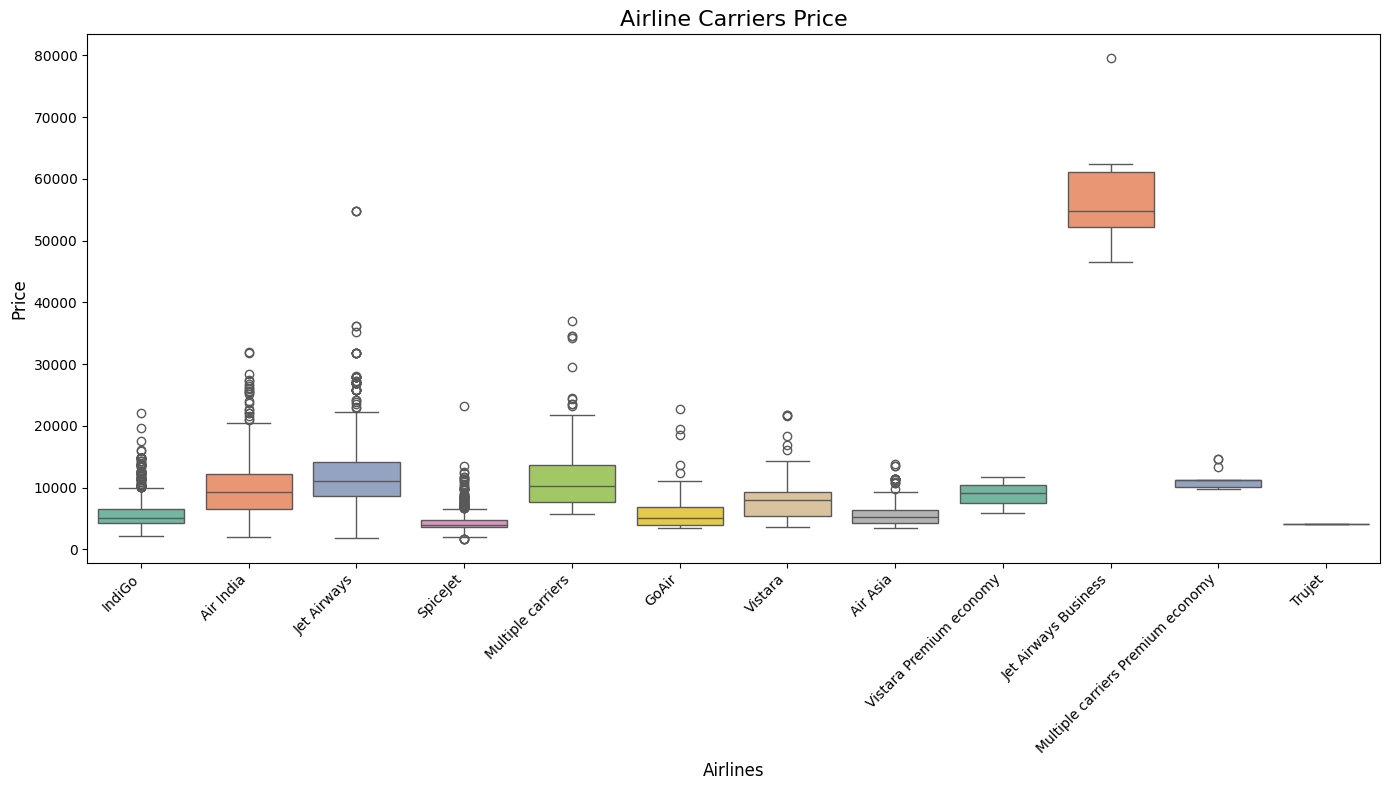

In [207]:
# Boxplot for "Airline" vs "Price"
plt.figure(figsize=(14, 8))
sns.boxplot(x='Airline', y='Price', data=df, palette='Set2')
plt.title("Airline Carriers Price", fontsize=16)
plt.xlabel("Airlines", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **📁Save Clean Data**

In [208]:
df.to_csv('Cleaned_Data.xlsx')

# **📊Visualization**

In [209]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info',
       'Price', 'Journey_Day', 'Journey_Month', 'Duration_Hours',
       'Duration_Minutes', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour',
       'Arrival_Minute'],
      dtype='object')

## 💹**Analysis by graphs**

### Distribution of Ticket Prices

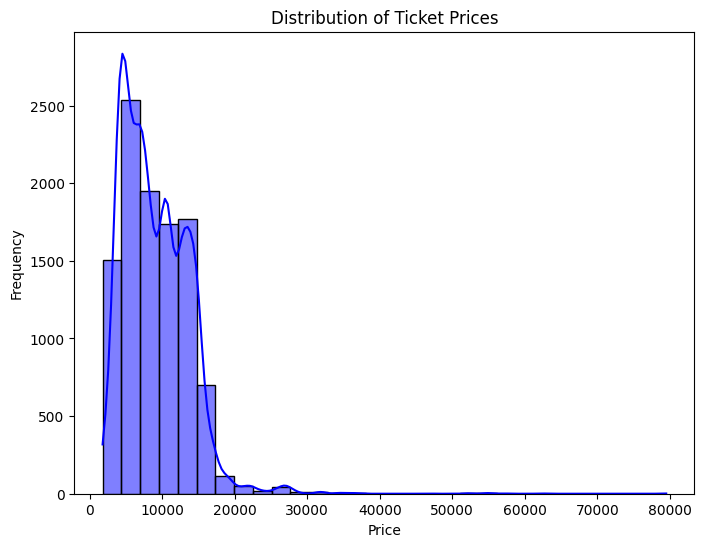

In [210]:
# Assuming 'data' is your DataFrame with the 'Price' column
plt.figure(figsize=(8, 6))
sns.histplot(df['Price'], bins=30, kde=True, color='blue')
plt.title('Distribution of Ticket Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


### ***Average Price by Airline***

<ipython-input-211-bf4330de22c1>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




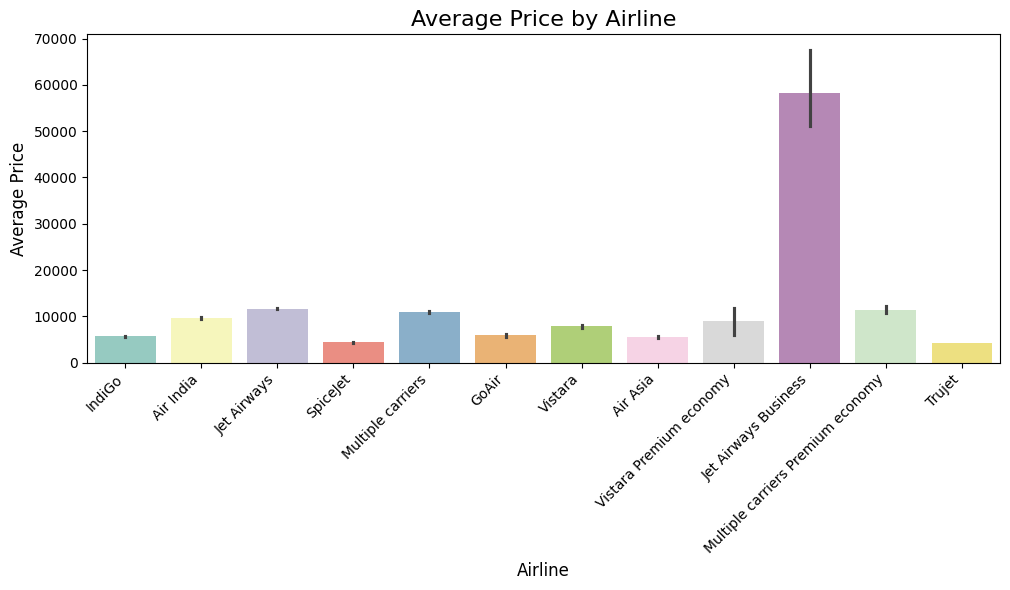

In [211]:
from matplotlib.patches import Patch

# Bar plot for Airline vs Average Price
plt.figure(figsize=(12, 6))
sns.barplot(x='Airline', y='Price', data=df, estimator='mean', palette='Set3')

# Add a smaller legend manually
legend_labels = df['Airline'].unique()
colors = plt.cm.tab20(range(len(legend_labels)))

plt.title("Average Price by Airline", fontsize=16)
plt.xlabel("Airline", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()


### **Average Price by Total Stops**

<ipython-input-212-a5bf4728c54e>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-212-a5bf4728c54e>:4: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



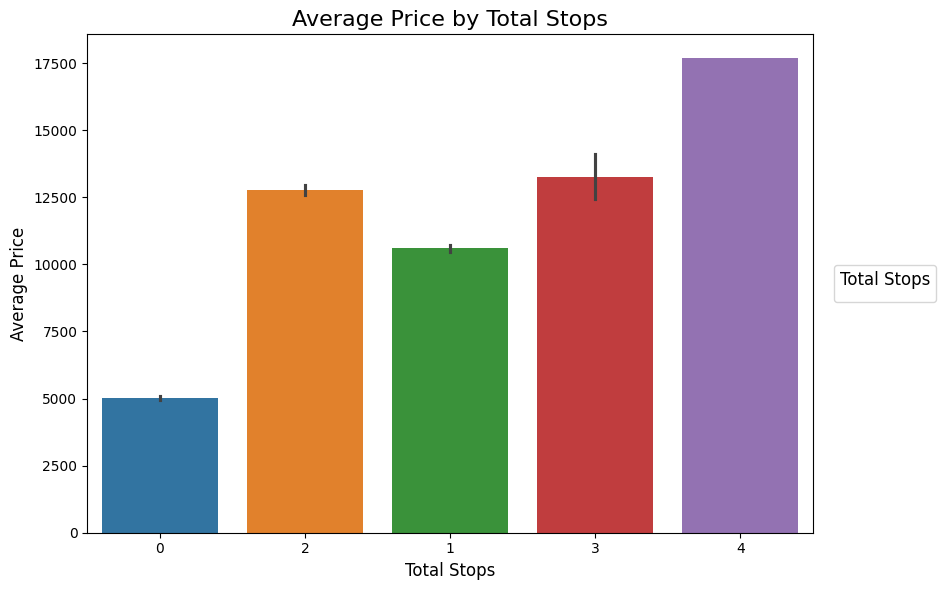

In [212]:
plt.figure(figsize=(12, 6))
color_map = sns.color_palette('tab10', n_colors=len(df['Total_Stops'].unique()))
sns.barplot(x='Total_Stops', y='Price', data=df, estimator='mean', palette=color_map)
plt.legend(title="Total Stops", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, fontsize=10, title_fontsize=12)

plt.title("Average Price by Total Stops", fontsize=16)
plt.xlabel("Total Stops", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.xticks(rotation=0, ha='center')

plt.tight_layout(rect=[0, 0, 0.8, 1])

plt.show()


### Average Ticket Price by Source

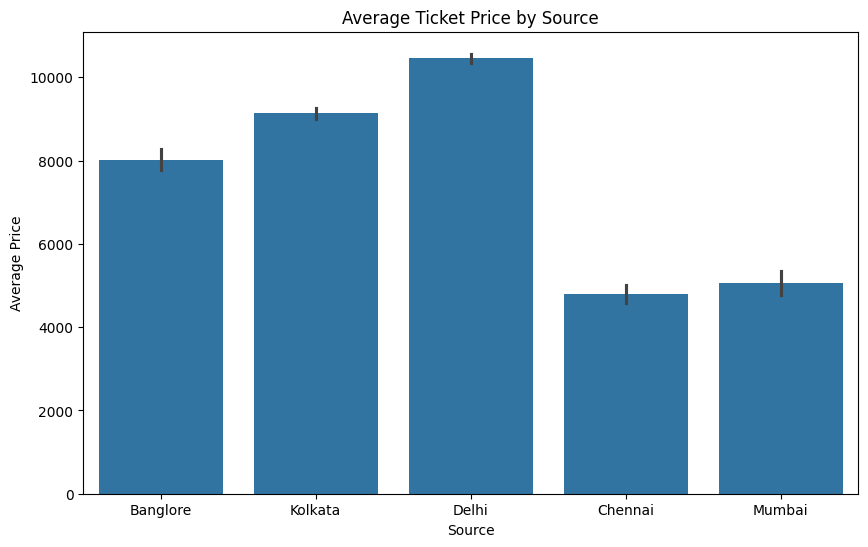

In [213]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Source', y='Price')
plt.title('Average Ticket Price by Source')
plt.xlabel('Source')
plt.ylabel('Average Price')
plt.show()

### ***Average Ticket Price by Additional_Info***

<ipython-input-214-abf183e799d4>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




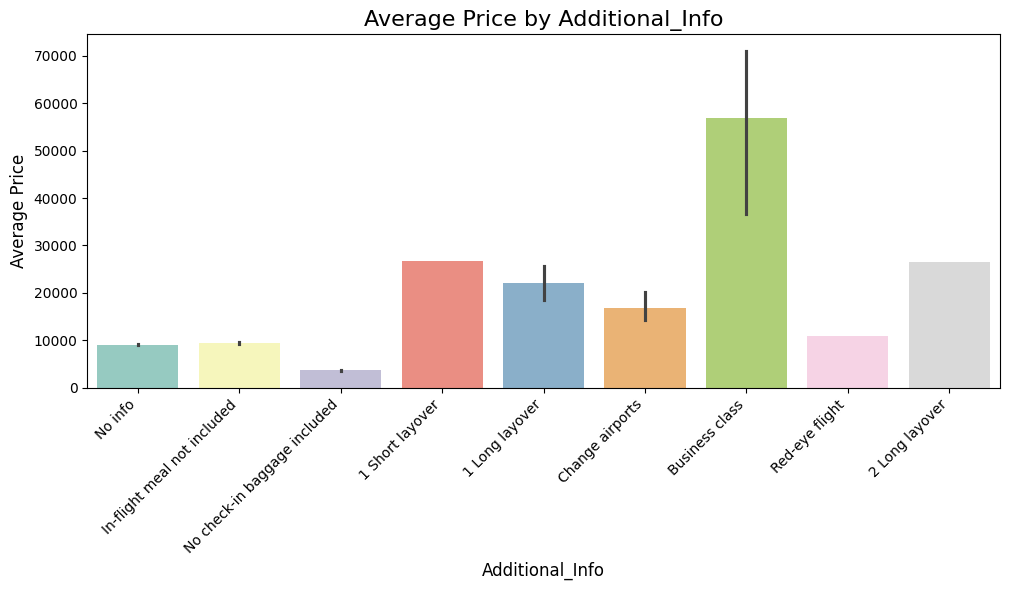

In [214]:
from matplotlib.patches import Patch

# Bar plot for Airline vs Average Price
plt.figure(figsize=(12, 6))
sns.barplot(x='Additional_Info', y='Price', data=df, estimator='mean', palette='Set3')

# Add a smaller legend manually
legend_labels = df['Additional_Info'].unique()
colors = plt.cm.tab20(range(len(legend_labels)))

plt.title("Average Price by Additional_Info", fontsize=16)
plt.xlabel("Additional_Info", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()


### ***Average Ticket Price by Journey_Month***

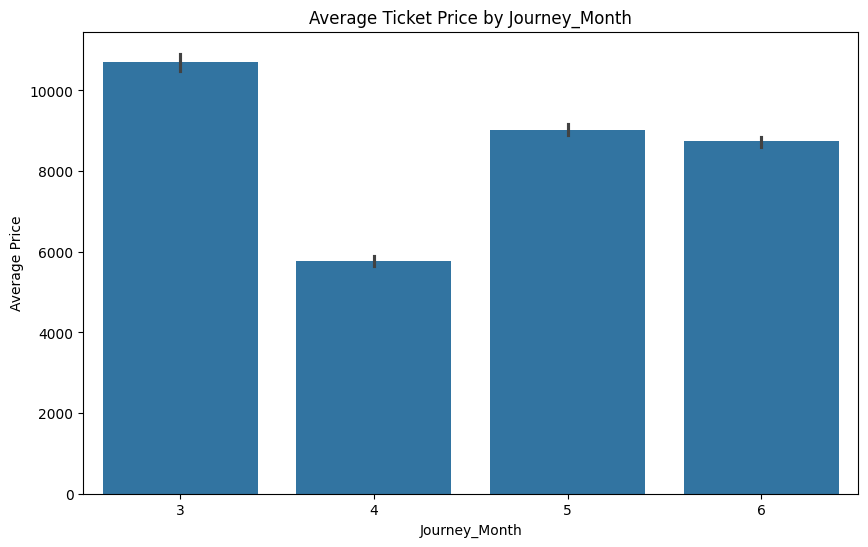

In [215]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Journey_Month', y='Price')
plt.title('Average Ticket Price by Journey_Month')
plt.xlabel('Journey_Month')
plt.ylabel('Average Price')
plt.show()

### ***Average Ticket Price by Journey_Day***

<ipython-input-216-f145c01af298>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




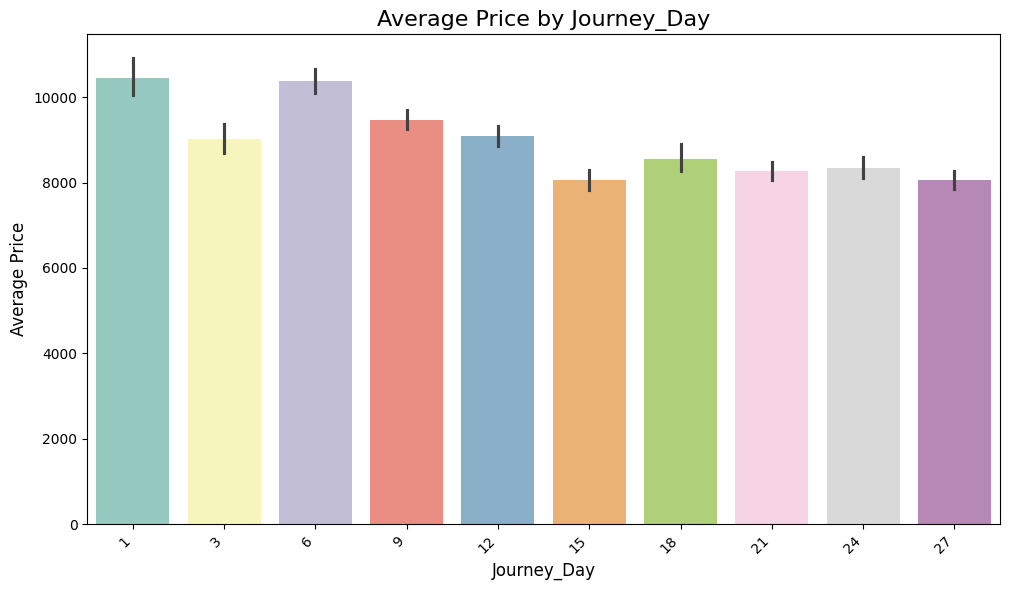

In [216]:
from matplotlib.patches import Patch

# Bar plot for Airline vs Average Price
plt.figure(figsize=(12, 6))
sns.barplot(x='Journey_Day', y='Price', data=df,estimator='mean', palette='Set3')

# Add a smaller legend manually
legend_labels = df['Journey_Day'].unique()
colors = plt.cm.tab20(range(len(legend_labels)))

plt.title("Average Price by Journey_Day", fontsize=16)
plt.xlabel("Journey_Day", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()


### ***Average Ticket Price by Duration_Hours***

<ipython-input-217-678f4e514c79>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




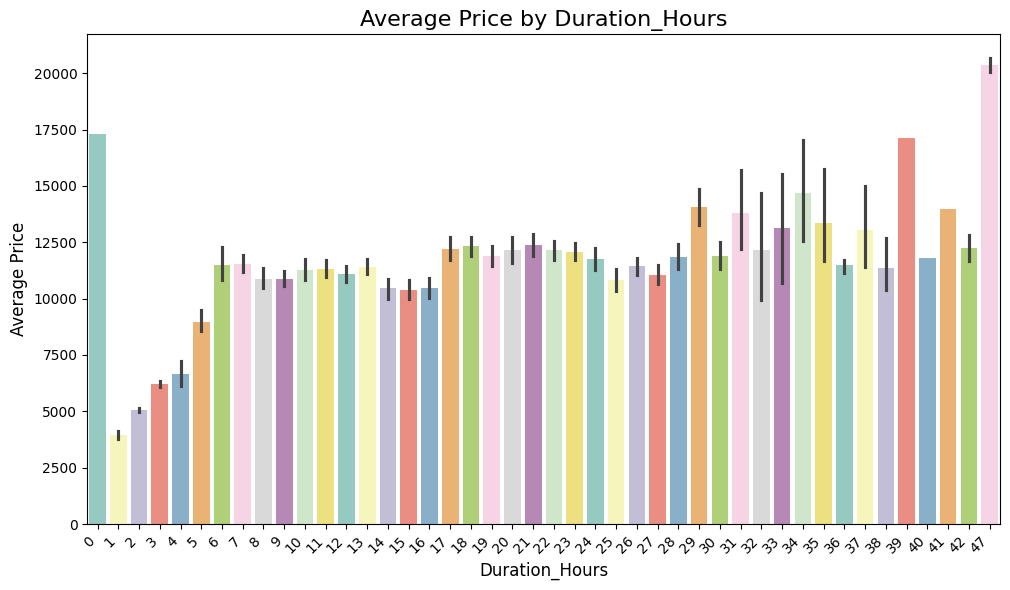

In [217]:
from matplotlib.patches import Patch

# Bar plot for Airline vs Average Price
plt.figure(figsize=(12, 6))
sns.barplot(x='Duration_Hours', y='Price', data=df,estimator='mean', palette='Set3')

# Add a smaller legend manually
legend_labels = df['Duration_Hours'].unique()
colors = plt.cm.tab20(range(len(legend_labels)))

plt.title("Average Price by Duration_Hours", fontsize=16)
plt.xlabel("Duration_Hours", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust plot area to make space for the legend
plt.show()


## ***🔗 Check Correlation***

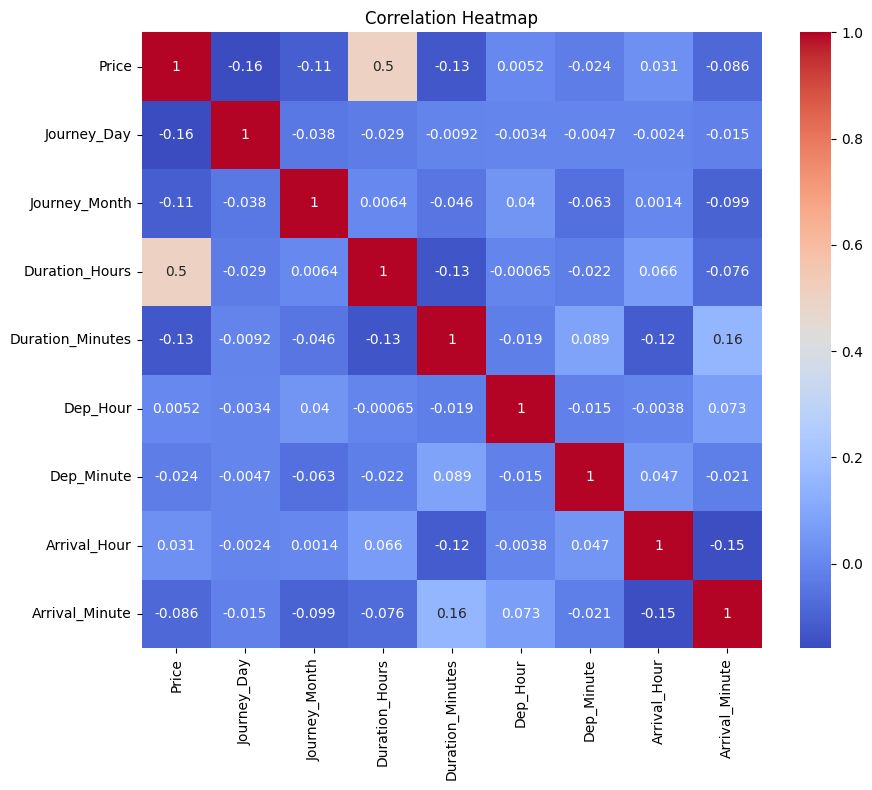

In [218]:
plt.figure(figsize=(10, 8))
Num_Columns = df.select_dtypes(include="number")
correlation_matrix = Num_Columns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# ***🛠Feature Engineering***

### **🔤Encoding**

In [219]:
# Encode categorical features using LabelEncoder
label_encoder = LabelEncoder()
categorical_columns = ['Airline', 'Source', 'Destination', 'Additional_Info']
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

### **📈Scalar**

In [220]:
scaler = StandardScaler()
numerical_columns = df.columns[df.dtypes != 'object']  # Select numeric columns
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# **💠Models**

In [221]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info',
       'Price', 'Journey_Day', 'Journey_Month', 'Duration_Hours',
       'Duration_Minutes', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour',
       'Arrival_Minute'],
      dtype='object')

In [222]:
data2=df.copy()

## ***✂️Spliting Data***

into Features , Target

In [223]:
X = data2.drop('Price', axis=1)
y = data2['Price']

In [224]:
print(X.shape)
print(y.shape)

(10462, 13)
(10462,)


In [225]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## ***🔄Apply Models and Evaluation***


In [227]:
from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor

In [228]:
models = {
    "RandomForestRegressor": RandomForestRegressor(),
    "LinearRegression": LinearRegression(),
    "SVR": SVR(),
    "Lasso": Lasso(),
    "GradientBoostingRegressor": GradientBoostingRegressor()
}


In [229]:
results = {}
for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    results[model_name] = {
        "Mean Squared Error": mse,
        "R2 Score": r2,
        "Training Score": round(train_score*100,2),
        "Testing Score": round(test_score*100,2),
        "Overfitting": train_score - test_score > 0.1
    }

In [230]:
for model_name, result in results.items():
    print(f"Model: {model_name}")
    print(f"Mean Squared Error: {result['Mean Squared Error']}")
    print(f"R2 Score: {result['R2 Score']}")
    print(f"Training Score: {result['Training Score']} %")
    print(f"Testing Score: {result['Testing Score']} %")
    print(f"Overfitting: {result['Overfitting']}")
    print("-" * 30)

Model: RandomForestRegressor
Mean Squared Error: 21.217667998554813
R2 Score: -20.764041072925657
Training Score: 97.93 %
Testing Score: -2076.4 %
Overfitting: True
------------------------------
Model: LinearRegression
Mean Squared Error: 0.5414109124865393
R2 Score: 0.4446472940622037
Training Score: 43.24 %
Testing Score: 44.46 %
Overfitting: False
------------------------------
Model: SVR
Mean Squared Error: 2.0918132511340164
R2 Score: -1.145679229106224
Training Score: 63.85 %
Testing Score: -114.57 %
Overfitting: True
------------------------------
Model: Lasso
Mean Squared Error: 0.975620122120422
R2 Score: -0.0007431736064431593
Training Score: 0.0 %
Testing Score: -0.07 %
Overfitting: False
------------------------------
Model: GradientBoostingRegressor
Mean Squared Error: 28.771803506350455
R2 Score: -28.512702022531844
Training Score: 83.3 %
Testing Score: -2851.27 %
Overfitting: True
------------------------------


## ***✴The Best Model***

* *RandomForestRegressor*

In [231]:
pipeline = Pipeline([
    ("model", RandomForestRegressor())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

model = pipeline.named_steps["model"]
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)


print(f"Model:RandomForestRegressor")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")
print(f"Training Score: {round(train_score*100,2)} %")
print(f"Testing Score: {round(test_score*100,2)} %")
print(f"Overfitting: {train_score - test_score > 0.1}")
print("-" * 30)

Model:RandomForestRegressor
Mean Squared Error: 16.70713973382094
R2 Score: -16.137362852635547
Training Score: 97.99 %
Testing Score: -1613.74 %
Overfitting: True
------------------------------


In [232]:
pipeline["model"].get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

### **Grid Search CV**

In [233]:
modeel= RandomForestRegressor()
param={}
param = {
    'regressor': [modeel],
    'regressor__n_estimators': [100, 200, 300,400],  # Changed 'model__' to 'regressor__'
    'regressor__max_depth': [None,3, 5,]  # Changed 'model__' to 'regressor__'
}

In [234]:
pipeline_best = Pipeline([
    ("regressor", modeel)
])
params=[param]

In [235]:
#Grid Search CV

grid_search = GridSearchCV(pipeline_best, params, cv=3, return_train_score=True).fit(X_train, y_train)

In [236]:
grid_search.best_params_

{'regressor': RandomForestRegressor(),
 'regressor__max_depth': None,
 'regressor__n_estimators': 300}

In [237]:
print(round(grid_search.best_score_*100,2),'%')

85.4 %


In [238]:
print(round(grid_search.cv_results_["mean_test_score"].mean()*100,2),"%")

69.12 %


In [239]:
print(round(grid_search.cv_results_["mean_train_score"].mean()*100,2),"%")

75.66 %


In [240]:
grid_search.best_estimator_

Pipeline(steps=[('regressor', RandomForestRegressor(n_estimators=300))])

### Randomized Search CV

In [241]:
Randomized_Search = RandomizedSearchCV(pipeline_best, params, cv=3, scoring='r2', return_train_score=True).fit(X_train, y_train)

In [242]:
Randomized_Search.best_params_

{'regressor__n_estimators': 100,
 'regressor__max_depth': None,
 'regressor': RandomForestRegressor()}

In [243]:
print(round(Randomized_Search.best_score_*100,2),'%')

85.27 %


### ***Apply best model***

In [244]:
pipeline = Pipeline([
    ("model", RandomForestRegressor())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

model = pipeline.named_steps["model"]
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)


print(f"Training Score: {round(train_score*100,2)} %")
print(f"Testing Score: {round(test_score*100,2)} %")

print(f"Model:RandomForestRegressor")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

print(f"Overfitting: {train_score - test_score > 0.1}")
print("-" * 30)

Training Score: 97.95 %
Testing Score: -1657.16 %
Model:RandomForestRegressor
Mean Squared Error: 17.130505810534526
R2 Score: -16.571630967449362
Overfitting: True
------------------------------


# **🈺Application**

In [245]:
joblib.dump(pipeline , "Third_Group.pkl")
joblib.dump(X.columns,"Inputs.pkl")

['Inputs.pkl']

In [246]:
X.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info',
       'Journey_Day', 'Journey_Month', 'Duration_Hours', 'Duration_Minutes',
       'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute'],
      dtype='object')

In [247]:
!pip install streamlit

In [248]:
%%writefile Third_app.py
import joblib
import pandas as pd
import streamlit as st

# Load the model and input features
model = joblib.load("Third_Group.pkl")
inputs = joblib.load("Inputs.pkl")

# Function for prediction
def prediction(Airline, Source, Destination, Total_Stops, Journey_Day, Journey_Month, Dep_Hour, Dep_Minute, Arrival_Hour, Arrival_Minute, Duration_Minutes):
    df = pd.DataFrame(columns=inputs)
    df.at[0, "Airline"] = Airline
    df.at[0, "Source"] = Source
    df.at[0, "Destination"] = Destination
    df.at[0, "Total_Stops"] = Total_Stops
    df.at[0, "Journey_Day"] = Journey_Day
    df.at[0, "Journey_Month"] = Journey_Month
    df.at[0, "Dep_Hour"] = Dep_Hour
    df.at[0, "Dep_Minute"] = Dep_Minute
    df.at[0, "Arrival_Hour"] = Arrival_Hour
    df.at[0, "Arrival_Minute"] = Arrival_Minute
    df.at[0, "Duration_Minutes"] = Duration_Minutes
    result = model.predict(df)[0]
    return result

# Main application
def main():
    st.markdown(
        """
        <style>
        body {
            font-family: 'Press Start 2P', cursive;
            color: #FFFFFF;
            background-color: #1E1E1E;
        }
        .stButton>button {
            background-color: #00BFFF;
            color: #FFFFFF;
            font-size: 18px;
            border-radius: 5px;
        }
        </style>
        """,
        unsafe_allow_html=True
    )

    st.title("Flight Fare Prediction")
    # Tabs for navigation
    tab1, tab2 = st.tabs(["About the App", "Prediction"])

    with tab1:
        st.image("download.jpg")
        st.write(
            "Welcome to the Flight Fare Prediction App! This application helps users estimate flight ticket prices "
            "based on various travel factors such as airline, source, destination, and journey details."
        )
        st.write(
            "### About the Developer\n"
            "Passionate about data science and machine learning, my goal is to leverage technology to create solutions that matter."
        )

    with tab2:
        st.header("Flight Fare Prediction")
        # Input fields
        Airline = st.selectbox("Airline", ["IndiGo", "Air India", "Jet Airways", "SpiceJet", "Multiple carriers", "GoAir", "Vistara", "Air Asia"])
        Source = st.selectbox("Source", ["Banglore", "Kolkata", "Delhi", "Chennai", "Mumbai"])
        Destination = st.selectbox("Destination", ["New Delhi", "Banglore", "Cochin", "Kolkata", "Delhi", "Hyderabad"])
        Total_Stops = st.selectbox("Total Stops", ["non-stop", "1 stop", "2 stops", "3 stops", "4 stops"])
        Journey_Day = st.slider("Journey Day", min_value=1, max_value=31, step=1)
        Journey_Month = st.slider("Journey Month", min_value=1, max_value=12, step=1)
        Dep_Hour = st.slider("Departure Hour", min_value=0, max_value=23, step=1)
        Dep_Minute = st.slider("Departure Minute", min_value=0, max_value=59, step=1)
        Arrival_Hour = st.slider("Arrival Hour", min_value=0, max_value=23, step=1)
        Arrival_Minute = st.slider("Arrival Minute", min_value=0, max_value=59, step=1)
        Duration_Minutes = st.number_input("Duration Minutes", min_value=0)

        if st.button("Predict Fare"):
            result = prediction(Airline, Source, Destination, Total_Stops, Journey_Day, Journey_Month, Dep_Hour, Dep_Minute, Arrival_Hour, Arrival_Minute, Duration_Minutes)
            st.success(f"Estimated Ticket Price: {result:.2f}")

if __name__ == "__main__":
    main()


Overwriting Third_app.py


# Run Files

In [249]:
!pip install pyngrok

In [255]:
import os
from pyngrok import ngrok

# تشغيل Streamlit في الخلفية
os.system("streamlit run Third_app.py &")

# فتح نفق ngrok بعد التأكد من أن Streamlit يعمل
public_url = ngrok.connect(8501)
print(f"🔗 Public URL: {public_url}")


🔗 Public URL: NgrokTunnel: "https://d18c-34-106-177-98.ngrok-free.app" -> "http://localhost:8501"


In [251]:
from pyngrok import ngrok

# الحصول على قائمة الأنفاق المفتوحة
tunnels = ngrok.get_tunnels()

# إغلاق كل الأنفاق المفتوحة
for tunnel in tunnels:
    ngrok.disconnect(tunnel.public_url)

print("✅ جميع الأنفاق السابقة تم إغلاقها.")


✅ جميع الأنفاق السابقة تم إغلاقها.


In [252]:
import os
from pyngrok import ngrok

# استبدل "YOUR_AUTH_TOKEN" بالتوكن الفعلي من حسابك في ngrok
os.system("ngrok authtoken 2ssCjNsbGXTcCK4KAqWbEFtEvAP_45ewCmqibVamYnfS7QJvD")

print("✅ تم تسجيل الـ authtoken بنجاح!")


✅ تم تسجيل الـ authtoken بنجاح!


In [253]:
import os
from pyngrok import ngrok

# تشغيل Streamlit في الخلفية
os.system("streamlit run Third_app.py &")

# فتح ngrok للحصول على رابط عام
public_url = ngrok.connect(8501)
print(f"Public URL: {public_url}")


Public URL: NgrokTunnel: "https://90d0-34-106-177-98.ngrok-free.app" -> "http://localhost:8501"


In [254]:
import os
print(os.listdir())  # يعرض جميع الملفات في المسار الحالي


['.config', 'download.jpg', 'Third_Group.pkl', 'Cleaned_Data.xlsx', 'Third_app.py', 'Data_Train.xlsx', 'Inputs.pkl', 'sample_data']
